# Complexity Estimate Statistical Testing: Forecasting Error Across CE Groups

This notebook implements the report's CE-focused statistical analysis. It filters extreme CE values, divides the selected series into four CE groups, visualises forecasting error across those groups, and applies Spearman correlation, Kruskal-Wallis, and Nemenyi post-hoc tests.

**Report references:** Sections 2.1 (*Complexity Measures*), 4.1 (*Forecasting Error Across Complexity Estimate Groups*), 4.1.1 (*Statistical Testing*), and Appendix B.

## 1. Imports and statistical helper functions

This cell imports the data, plotting, and statistical-testing libraries used in the CE analysis. It also defines helper functions for group-size summaries and p-value significance labels, matching the star notation used in the report figures and appendix tables.

**Report references:** Section 4.1.1 (*Statistical Testing*) and Appendix B.


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr, kruskal, wilcoxon
from sklearn.linear_model import LinearRegression
from itertools import combinations
import scikit_posthocs as sp
import warnings
warnings.filterwarnings("ignore")

ALPHA = 0.05

def summarise_group_sizes(df, group_cols):
    """Count, total % and small group flag."""
    counts = df.groupby(group_cols, observed=True).size().reset_index(name="n")
    counts["pct_total"]  = (counts["n"] / len(df) * 100).round(1)
    counts["small_group"] = counts["n"] < SMALL_N_THRESHOLD
    return counts

def stars(p):
    """p-value to * notation."""
    if pd.isna(p): return "—"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

final_df = pd.read_csv("../random_Forest_and_LightGBM_implementation/final_df.csv")
print(f"Shape: {final_df.shape}")
final_df.head()

Shape: (400, 39)


,unique_id,size,complexity,transformations,n_transformations,final_status,nmae_AutoARIMA,nrmse_AutoARIMA,smape_AutoARIMA,nmae_naive,...,%smape_rf_vs_snaive,%nmae_rf_vs_naive,%nrmse_rf_vs_naive,%smape_rf_vs_naive,%nmae_lgbm_vs_snaive,%nrmse_lgbm_vs_snaive,%smape_lgbm_vs_snaive,%nmae_lgbm_vs_naive,%nrmse_lgbm_vs_naive,%smape_lgbm_vs_naive
0,M80,585,22292.093,[],0,stationary,0.119518,0.154520,0.060977,0.323598,...,-17.301975,45.471753,33.563786,41.920767,-66.014391,-76.275456,-51.943723,26.407359,15.194129,24.768744
1,M160,91,273.198,['difference'],1,stationary,0.153033,0.178445,0.080407,0.148942,...,9.457929,7.118945,6.045789,7.781610,22.745157,22.154531,24.538795,21.509840,20.831313,23.141687
2,M251,289,2168.225,['difference'],1,stationary,0.599868,0.628307,0.234093,0.415595,...,69.502858,63.849701,46.796092,53.127818,41.900545,39.047328,14.458814,-8.926704,-16.260218,-31.471402
3,M293,150,5295.457,['detrend'],1,stationary,0.278123,0.306875,0.155947,0.248370,...,38.237085,27.788533,30.177392,39.014285,67.024745,53.860408,71.559229,69.069742,58.352119,71.917116
4,M591,142,372.494,['difference'],1,stationary,0.043832,0.049612,0.021588,0.028322,...,3.334105,-2.554489,-20.139130,-5.838130,-170.089922,-170.934467,-191.805904,-196.353062,-225.952364,-219.494182


## 2. Exploratory analysis of the Complexity Estimate distribution

This cell inspects the distribution of CE, its relationship with series length, and the effect of extreme CE values. This supports the later decision to remove observations above the 95th percentile before dividing the series into four complexity groups.

**Report references:** Section 2.1 (*Complexity Measures*) and Section 4.1 (*Forecasting Error Across Complexity Estimate Groups*).

Complexity Estimate's Descriptive Statistics
count       400.000000
mean       6056.682675
std       11522.535392
min         105.674000
25%        1022.011500
50%        2460.095000
75%        6681.474000
max      151557.085000
Name: complexity, dtype: float64

Correlation between complexity and series size
            complexity      size
complexity    1.000000 -0.045761
size         -0.045761  1.000000


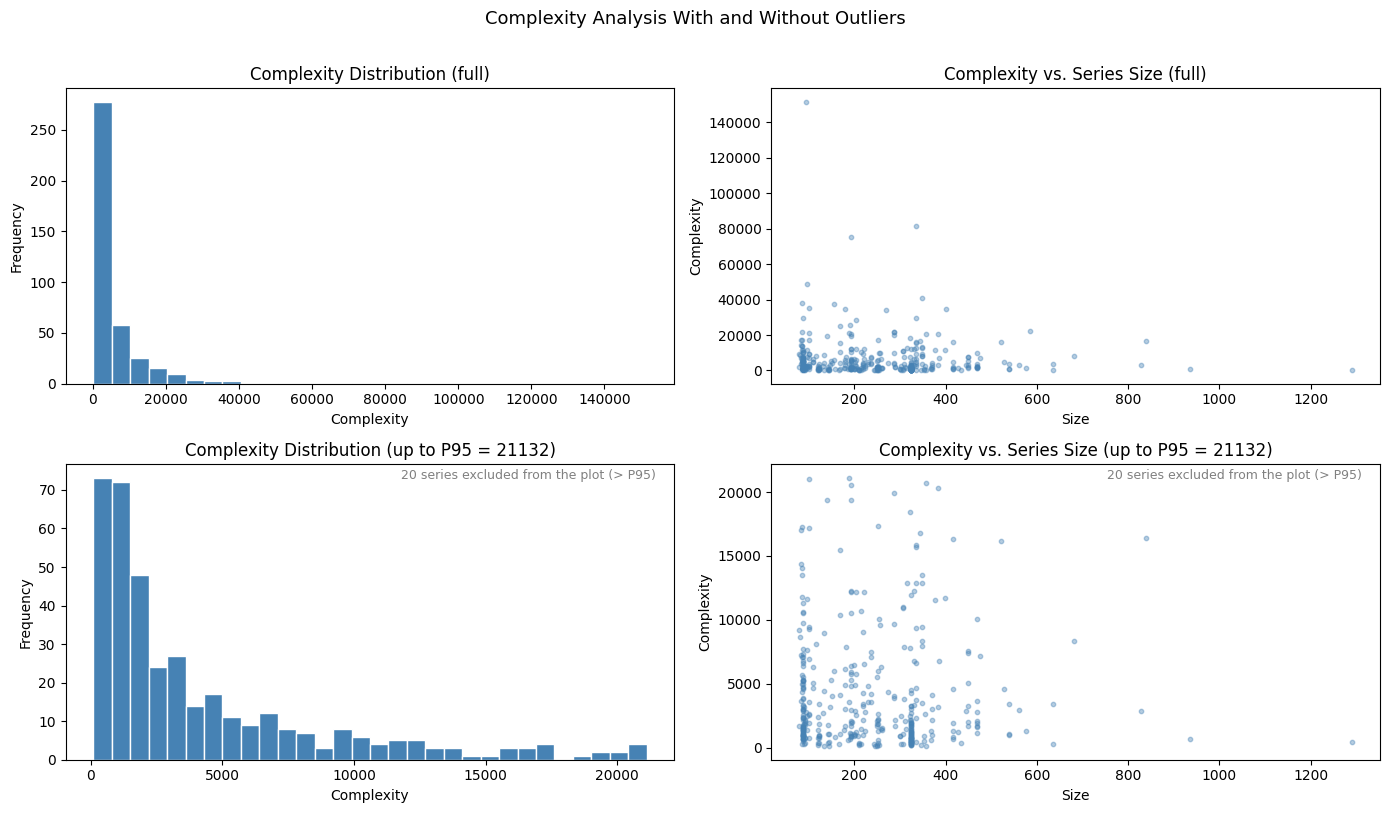

In [21]:
print("Complexity Estimate's Descriptive Statistics")
print(final_df["complexity"].describe())

print("\nCorrelation between complexity and series size")
print(final_df[["complexity", "size"]].corr())

p95 = final_df["complexity"].quantile(0.95)
n_outliers = (final_df["complexity"] > p95).sum()
df_no_outliers = final_df[final_df["complexity"] <= p95]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(final_df["complexity"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Complexity Distribution (full)")
axes[0, 0].set_xlabel("Complexity"); axes[0, 0].set_ylabel("Frequency")

axes[0, 1].scatter(final_df["size"], final_df["complexity"], alpha=0.4, s=10, color="steelblue")
axes[0, 1].set_title("Complexity vs. Series Size (full)")
axes[0, 1].set_xlabel("Size"); axes[0, 1].set_ylabel("Complexity")

axes[1, 0].hist(df_no_outliers["complexity"], bins=30, color="steelblue", edgecolor="white")
axes[1, 0].set_title(f"Complexity Distribution (up to P95 = {p95:.0f})")
axes[1, 0].set_xlabel("Complexity"); axes[1, 0].set_ylabel("Frequency")
axes[1, 0].annotate(f"{n_outliers} series excluded from the plot (> P95)",
                    xy=(0.97, 0.95), xycoords="axes fraction", ha="right", fontsize=9, color="gray")

axes[1, 1].scatter(df_no_outliers["size"], df_no_outliers["complexity"], alpha=0.4, s=10, color="steelblue")
axes[1, 1].set_title(f"Complexity vs. Series Size (up to P95 = {p95:.0f})")
axes[1, 1].set_xlabel("Size"); axes[1, 1].set_ylabel("Complexity")
axes[1, 1].annotate(f"{n_outliers} series excluded from the plot (> P95)",
                    xy=(0.97, 0.95), xycoords="axes fraction", ha="right", fontsize=9, color="gray")

plt.suptitle("Complexity Analysis With and Without Outliers", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 3. Remove extreme CE values and create four CE groups

Remove series above the 95th percentile of CE and then divides the remaining series into four equal-sized groups. These groups are used as the independent samples for the boxplots and statistical tests.

**Report references:** Section 4.1 (*Forecasting Error Across Complexity Estimate Groups*) and Table 2.


In [22]:
P95_THRESHOLD  = final_df["complexity"].quantile(0.95)
SMALL_N_THRESHOLD = 30

df = final_df[final_df["complexity"] <= P95_THRESHOLD].copy()

df["complexity_group"] = pd.qcut(
    df["complexity"],
    q=4,
    labels=["G1(low)", "G2", "G3", "G4(high)"]
)

print(f"Removed Series (> P95 = {P95_THRESHOLD:.0f}): {len(final_df) - len(df)}")
print(f"Series left: {len(df)}\n")
print(summarise_group_sizes(df, ["complexity_group"]).to_string(index=False))

Removed Series (> P95 = 21132): 20
Series left: 380

complexity_group  n  pct_total  small_group
         G1(low) 95       25.0        False
              G2 95       25.0        False
              G3 95       25.0        False
        G4(high) 95       25.0        False


## 4. Descriptive statistics by CE group

This cell summarises the minimum, maximum, mean, and median CE values for each group. These values document the range of complexity covered by each group after outlier removal.

**Report reference:** Section 4.1, Table 2 (*Descriptive statistics of Complexity Estimate by complexity group*).


In [23]:
df.groupby("complexity_group", observed=True)["complexity"].agg(["min", "max", "mean", "median"]).round(2)

,min,max,mean,median
complexity_group,,,,
G1(low),105.67,998.15,561.49,559.55
G2,1007.24,2168.22,1518.79,1462.36
G3,2179.45,5524.49,3626.44,3409.05
G4(high),5696.99,21115.50,10966.46,9780.08


## 5. Define model, metric, and plotting configuration

The analysis compares the five forecasting approaches evaluated using the three complementary error metrics. The group order is fixed so that all later plots and tests follow the same low-to-high CE progression.

**Report references:** Section 3.2 (*Models*) and Section 3.2 (*Evaluation Metrics*).

In [24]:
MODELS = ["naive", "seasonal_naive", "AutoARIMA", "RF", "LGBM"]
METRICS  = ["nmae", "nrmse", "smape"]

MODEL_COLORS = {
    "AutoARIMA" : "#4878CF",
    "naive"     : "#A0A0A0",
    "seasonal_naive": "#C0C0C0",
    "RF"        : "#E07B39",
    "LGBM"      : "#2CA02C",
}

GROUP_ORDER = ["G1(low)", "G2", "G3", "G4(high)"]

## 6. Scatter plots of CE against forecasting error

These scatter plots provide an initial visual check of the relationship between CE and forecasting error for every model-metric pair. They help show whether higher CE values tend to be associated with higher error before formal statistical testing.

**Report references:** Section 4.1 (*Forecasting Error Across Complexity Estimate Groups*) and Section 4.1.1 (*Spearman Correlation*).


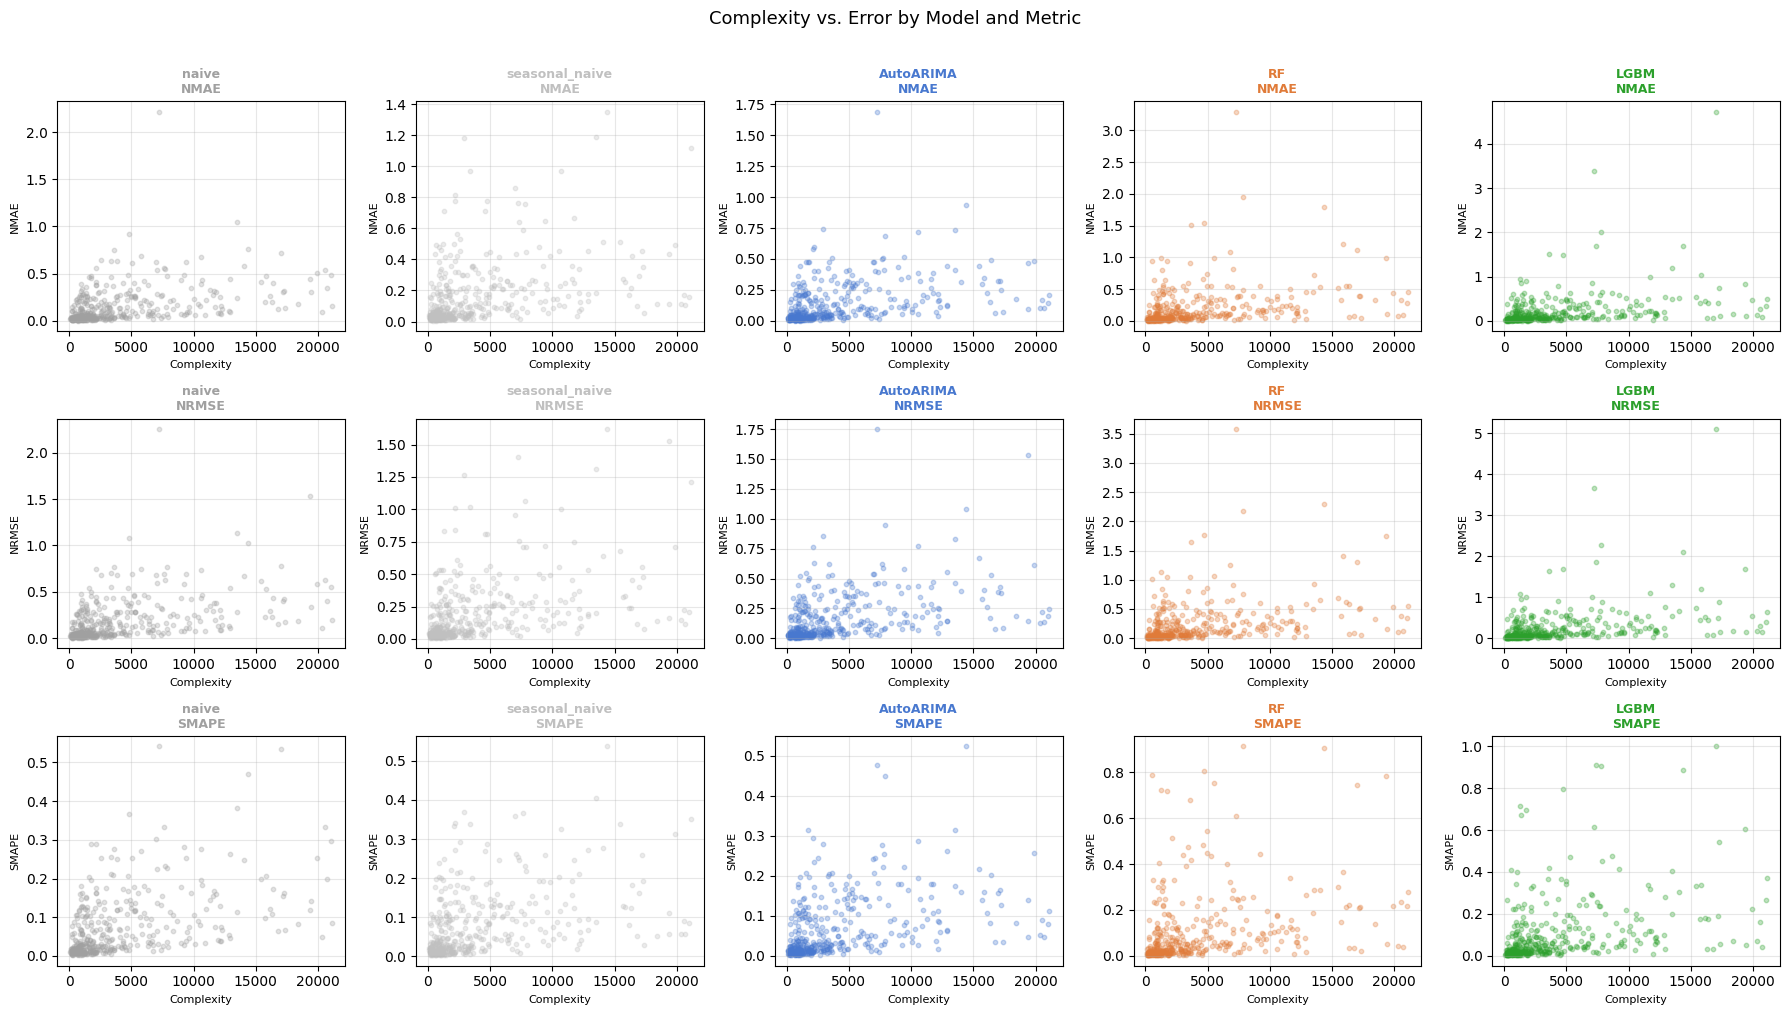

In [25]:
fig, axes = plt.subplots(len(METRICS), len(MODELS), figsize=(18, 10))

for r, metric in enumerate(METRICS):
    for c, model in enumerate(MODELS):
        ax = axes[r, c]
        col = f"{metric}_{model}"
        ax.scatter(df["complexity"], df[col], alpha=0.3, s=10, color=MODEL_COLORS[model])
        ax.set_xlabel("Complexity", fontsize=8)
        ax.set_ylabel(metric.upper(), fontsize=8)
        ax.set_title(f"{model}\n{metric.upper()}", fontsize=9, fontweight="bold", color=MODEL_COLORS[model])
        ax.grid(alpha=0.3)

plt.suptitle("Complexity vs. Error by Model and Metric", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Scatter plots excluding the highest CE group

This truncated view focuses on the lower and middle CE ranges so that the dense part of the distribution is easier to inspect. It complements the full scatter plots, where the highest-complexity series can dominate the axis scale.

**Report reference:** Section 4.1 (*Forecasting Error Across Complexity Estimate Groups*).


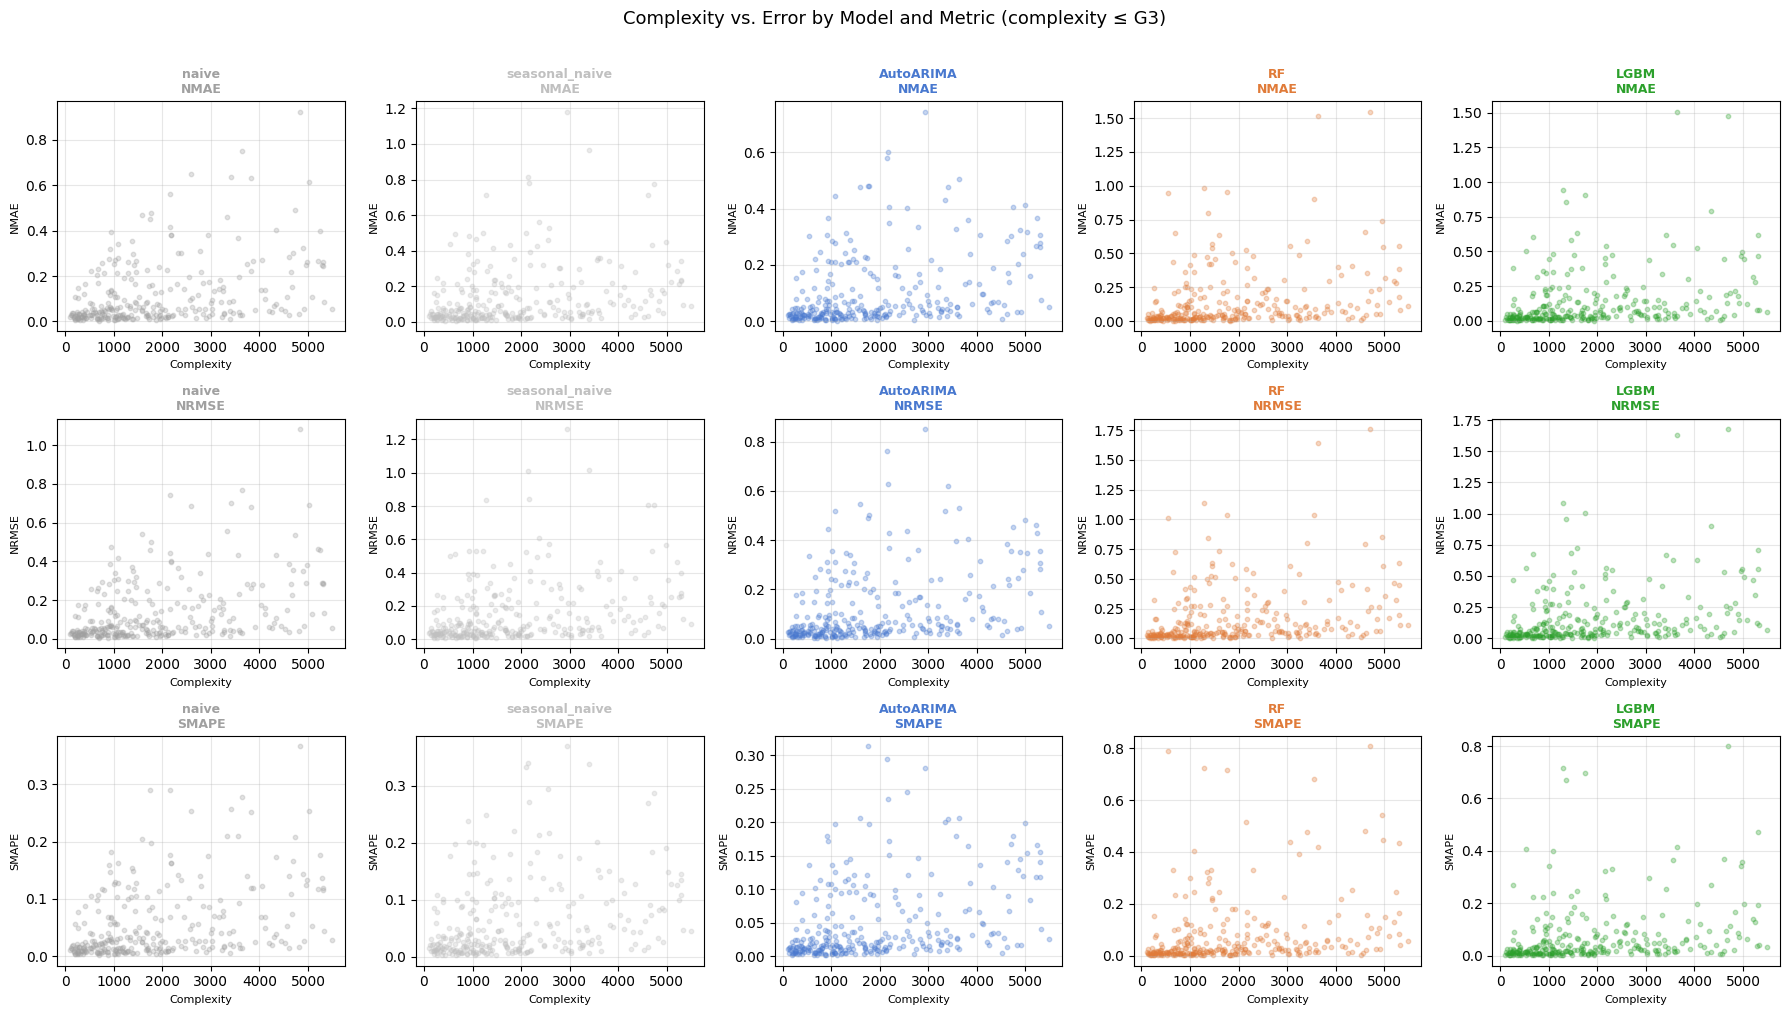

In [26]:
df_trunc = df[df["complexity"] <= 5516]

fig, axes = plt.subplots(len(METRICS), len(MODELS), figsize=(18, 10))

for r, metric in enumerate(METRICS):
    for c, model in enumerate(MODELS):
        ax = axes[r, c]
        col = f"{metric}_{model}"
        ax.scatter(df_trunc["complexity"], df_trunc[col], alpha=0.3, s=10, color=MODEL_COLORS[model])
        ax.set_xlabel("Complexity", fontsize=8)
        ax.set_ylabel(metric.upper(), fontsize=8)
        ax.set_title(f"{model}\n{metric.upper()}", fontsize=9, fontweight="bold", color=MODEL_COLORS[model])
        ax.grid(alpha=0.3)

plt.suptitle("Complexity vs. Error by Model and Metric (complexity ≤ G3)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Boxplots of forecasting error by CE group

For each metric and model, this cell compares the distribution of forecasting error across the four CE groups. These boxplots are the main visual evidence that error tends to increase as CE increases.

**Report references:** Section 4.1 (*Forecasting Error Across Complexity Estimate Groups*) and Figure 1.

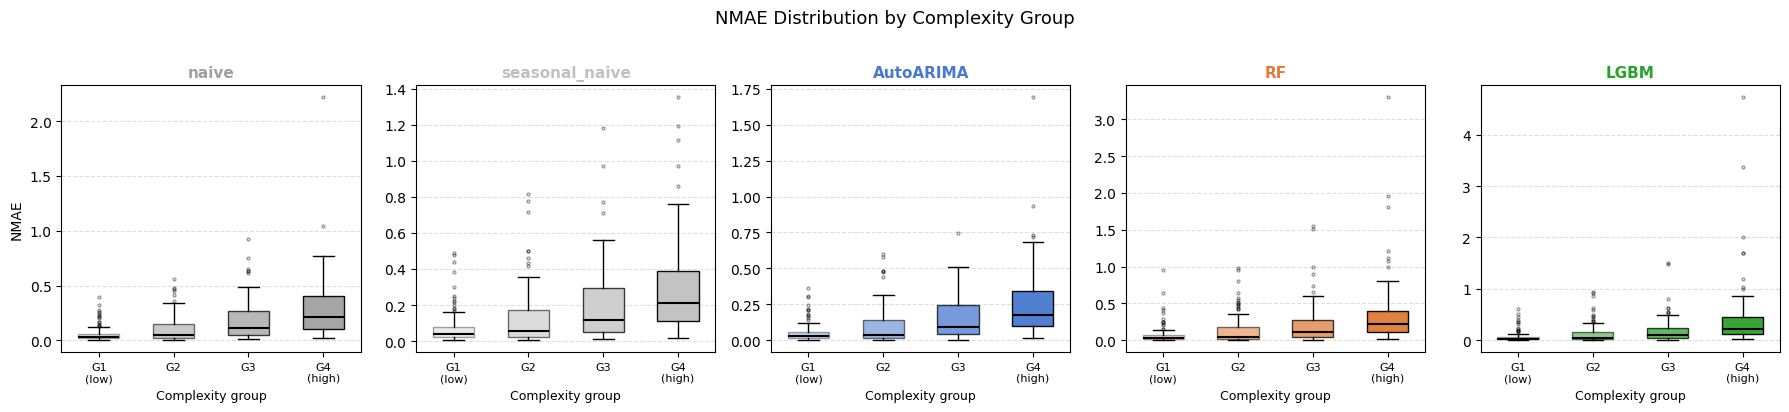

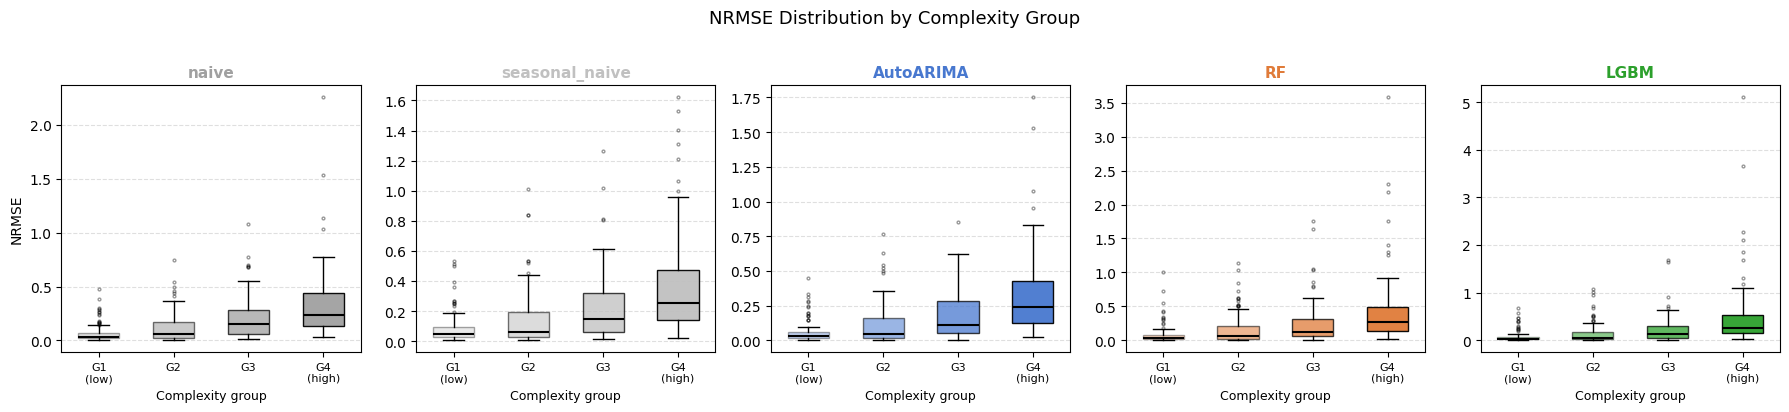

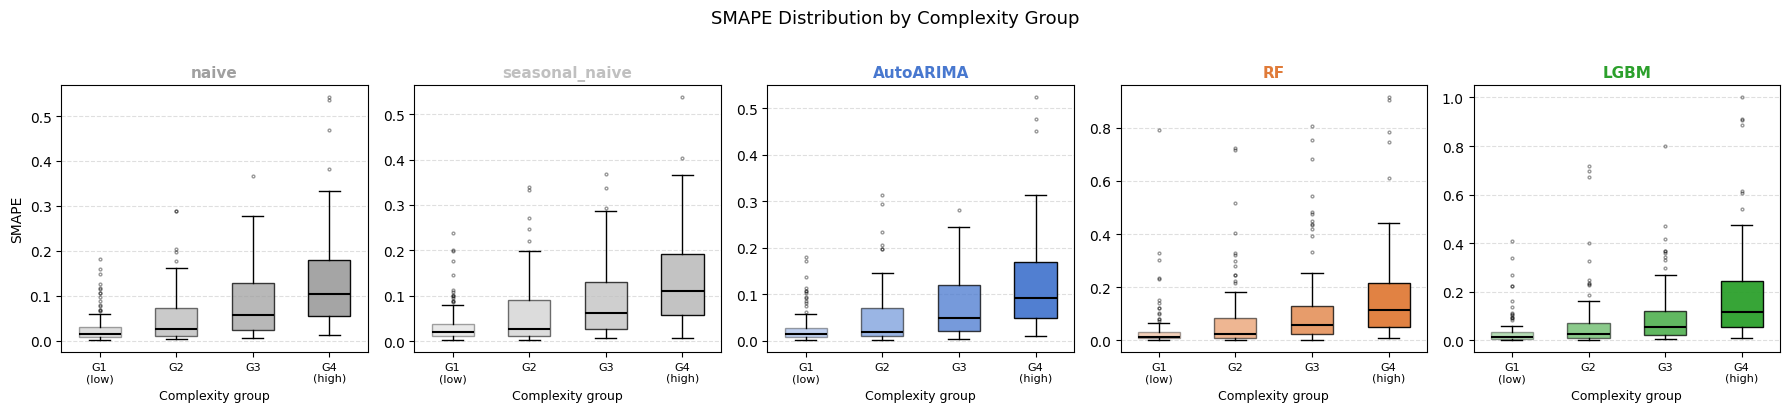

In [27]:
for metric in METRICS:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(18, 4), sharey=False)
    fig.suptitle(
        f"{metric.upper()} Distribution by Complexity Group",
        fontsize=13, y=1.02
    )
    for ax, model in zip(axes, MODELS):
        col = f"{metric}_{model}"
        data_by_group = [df[df["complexity_group"] == g][col].dropna().values
                         for g in GROUP_ORDER]
        bp = ax.boxplot(
            data_by_group,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=1.5),
            flierprops=dict(marker="o", markersize=2, alpha=0.4),
            widths=0.55,
        )
        color = MODEL_COLORS[model]
        alphas = [0.35, 0.55, 0.75, 0.95]
        for patch, a in zip(bp["boxes"], alphas):
            patch.set_facecolor(color)
            patch.set_alpha(a)
        ax.set_title(model, fontsize=11, fontweight="bold", color=color)
        ax.set_xticks(range(1, len(GROUP_ORDER) + 1))
        ax.set_xticklabels([g.replace("(", "\n(") for g in GROUP_ORDER], fontsize=8)
        ax.set_xlabel("Complexity group", fontsize=9)
        ax.set_ylabel(metric.upper() if ax == axes[0] else "")
        ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"boxplot_{metric}_by_complexity.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Median forecasting error by CE group

This cell computes the median error for every model, metric, and CE group. The medians provide a compact numerical summary of the pattern shown by the boxplots.

**Report reference:** Section 4.1 (*Forecasting Error Across Complexity Estimate Groups*).

In [28]:
rows = []
for metric in METRICS:
    for model in MODELS:
        col = f"{metric}_{model}"
        grp = df.groupby("complexity_group", observed=True)[col].median()
        for g, val in grp.items():
            rows.append({"metric": metric, "model": model, "group": g, "median": val})

summary_df = pd.DataFrame(rows)
pivot = summary_df.pivot_table(
    index=["metric", "model"], columns="group", values="median"
)
print("Medians by complexity quantile")
print(pivot.round(4).to_string())

Medians by complexity quantile
group                  G1(low)      G2      G3  G4(high)
metric model                                            
nmae   AutoARIMA        0.0268  0.0350  0.0919    0.1792
       LGBM             0.0287  0.0486  0.1011    0.2233
       RF               0.0263  0.0494  0.1110    0.2210
       naive            0.0324  0.0500  0.1160    0.2095
       seasonal_naive   0.0399  0.0540  0.1186    0.2127
nrmse  AutoARIMA        0.0311  0.0448  0.1138    0.2370
       LGBM             0.0320  0.0550  0.1207    0.2643
       RF               0.0311  0.0560  0.1225    0.2651
       naive            0.0370  0.0597  0.1536    0.2361
       seasonal_naive   0.0450  0.0614  0.1482    0.2551
smape  AutoARIMA        0.0134  0.0176  0.0484    0.0917
       LGBM             0.0143  0.0238  0.0530    0.1185
       RF               0.0130  0.0246  0.0581    0.1157
       naive            0.0160  0.0251  0.0570    0.1045
       seasonal_naive   0.0198  0.0277  0.0630    0.1101


## 10. Relative median gain against the baseline models

This cell compares AutoARIMA, Random Forest, and LightGBM against the Naive and Seasonal Naive baselines within each CE group. Positive values mean that the model improves over the baseline median error for that group.

**Report references:** Section 3.2 (*Models*) and Section 5 (*Discussion and Conclusion*), where the importance of baseline models is discussed.

In [29]:
baselines = ["naive", "seasonal_naive"]
models_of_interest = ["AutoARIMA", "LGBM", "RF"]

rows = []
for metric in METRICS:
    for group in GROUP_ORDER:
        grp_df = df[df["complexity_group"] == group]
        for model in models_of_interest:
            for baseline in baselines:
                col_model    = f"{metric}_{model}"
                col_baseline = f"{metric}_{baseline}"
                med_model    = grp_df[col_model].median()
                med_baseline = grp_df[col_baseline].median()
                gain = (med_baseline - med_model) / med_baseline * 100
                rows.append({
                    "metric"   : metric,
                    "group"    : group,
                    "model"    : model,
                    "baseline" : baseline,
                    "gain_%"   : round(gain, 1)
                })

gain_df = pd.DataFrame(rows)
pivot = gain_df.pivot_table(
    index=["metric", "model"],
    columns=["baseline", "group"],
    values="gain_%"
)

def bold_positive(val):
    return "font-weight: bold" if val > 0 else ""

print("Relative median gain (%) vs. baselines by complexity group")
print("(positive = better than the baseline)\n")
pivot.style.applymap(bold_positive).format("{:.1f}")

Relative median gain (%) vs. baselines by complexity group
(positive = better than the baseline)



## 11. Spearman correlation between CE and forecasting error

Spearman correlation is used because it measures association without assuming linearity or normally distributed variables, to quantify whether higher CE values are consistently associated with higher forecasting error.

**Report references:** Section 4.1.1 (*Spearman Correlation*) and Figure 2.

Spearman correlation: complexity vs. error

metric          model      rho      p_value sig
  nmae          naive 0.569223 5.168302e-34 ***
  nmae seasonal_naive 0.502794 9.718302e-26 ***
  nmae      AutoARIMA 0.565844 1.514527e-33 ***
  nmae             RF 0.523141 4.414281e-28 ***
  nmae           LGBM 0.546150 6.279845e-31 ***
 nrmse          naive 0.581982 7.955663e-36 ***
 nrmse seasonal_naive 0.524070 3.420786e-28 ***
 nrmse      AutoARIMA 0.577850 3.136558e-35 ***
 nrmse             RF 0.534173 2.028424e-29 ***
 nrmse           LGBM 0.559112 1.243902e-32 ***
 smape          naive 0.570827 3.089424e-34 ***
 smape seasonal_naive 0.508670 2.123969e-26 ***
 smape      AutoARIMA 0.567433 9.150010e-34 ***
 smape             RF 0.522098 5.872190e-28 ***
 smape           LGBM 0.545105 8.551401e-31 ***


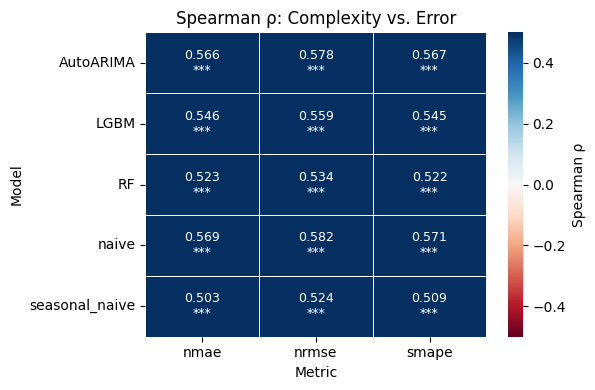

In [30]:
spearman_rows = []
for metric in METRICS:
    for model in MODELS:
        col = f"{metric}_{model}"
        rho, pval = spearmanr(df["complexity"], df[col].dropna())
        spearman_rows.append({
            "metric" : metric,
            "model"  : model,
            "rho"    : round(rho, 6),
            "p_value": round(pval, 100),
            "sig"    : stars(pval),
        })

spearman_df = pd.DataFrame(spearman_rows)
print("Spearman correlation: complexity vs. error\n")
print(spearman_df.to_string(index=False))

# Heatmap of rhos
pivot_rho = spearman_df.pivot_table(index="model", columns="metric", values="rho")
pivot_sig = spearman_df.pivot_table(index="model", columns="metric", values="sig",
                                    aggfunc="first")

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    pivot_rho, annot=False, fmt=".3f", cmap="RdBu",
    center=0, vmin=-0.5, vmax=0.5,
    linewidths=0.5, ax=ax, cbar_kws={"label": "Spearman ρ"}
)
# rho + stars annotation
for i, model in enumerate(pivot_rho.index):
    for j, metric in enumerate(pivot_rho.columns):
        rho_val = pivot_rho.loc[model, metric]
        sig_val = pivot_sig.loc[model, metric]
        ax.text(j + 0.5, i + 0.5, f"{rho_val:.3f}\n{sig_val}",
                ha="center", va="center", fontsize=9,
                color="white" if abs(rho_val) > 0.3 else "black")

ax.set_title("Spearman ρ: Complexity vs. Error", fontsize=12)
ax.set_xlabel("Metric"); ax.set_ylabel("Model")
plt.tight_layout()
plt.savefig("heatmap_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Kruskal-Wallis test across CE groups

The Kruskal-Wallis test checks whether the forecasting-error distributions differ across the four CE groups. It is appropriate here because it compares more than two independent groups without requiring normality.

**Report references:** Section 4.1.1 (*Kruskal-Wallis Test*) and Appendix B, Table 3.

In [31]:
kruskal_rows = []
for metric in METRICS:
    for model in MODELS:
        col = f"{metric}_{model}"
        groups = [
            df[df["complexity_group"] == g][col].dropna().values
            for g in GROUP_ORDER
        ]
        stat, pval = kruskal(*groups)

        # effect size e2 = (h_stat - n_groups + 1) / (n_obs - n_groups)        
        n = sum(len(g) for g in groups)
        k = len(groups)
        epsilon_sq = (stat - k + 1) / (n - k)
        if epsilon_sq < 0.06:
            magnitude = "low"
        elif epsilon_sq < 0.14:
            magnitude = "moderate"
        else:
            magnitude = "high"
            
        kruskal_rows.append({
            "metric"          : metric,
            "model"           : model,
            "H_stat"          : round(stat, 3),
            "p_value"         : pval,
            "epsilon_sq"      : round(epsilon_sq, 4),
            "effect_size"     : magnitude,
            "sig"             : stars(pval),
            "proceed_nemenyi" : pval < ALPHA,
        })
kruskal_df = pd.DataFrame(kruskal_rows)
print("Kruskal-Wallis: effect of complexity on performance\n")
print(kruskal_df.to_string(index=False))

Kruskal-Wallis: effect of complexity on performance

metric          model  H_stat      p_value  epsilon_sq effect_size sig  proceed_nemenyi
  nmae          naive 110.301 9.453707e-24      0.2854        high ***             True
  nmae seasonal_naive  91.798 9.000861e-20      0.2362        high ***             True
  nmae      AutoARIMA 111.429 5.404975e-24      0.2884        high ***             True
  nmae             RF  92.040 7.987035e-20      0.2368        high ***             True
  nmae           LGBM 103.278 3.066553e-22      0.2667        high ***             True
 nrmse          naive 115.162 8.497397e-25      0.2983        high ***             True
 nrmse seasonal_naive  99.299 2.198692e-21      0.2561        high ***             True
 nrmse      AutoARIMA 115.987 5.642894e-25      0.3005        high ***             True
 nrmse             RF  96.070 1.087458e-20      0.2475        high ***             True
 nrmse           LGBM 108.052 2.880930e-23      0.2794        high 

## 13. Nemenyi post-hoc test for pairwise CE-group comparisons

When Kruskal-Wallis is significant, the Nemenyi post-hoc test identifies which pairs of CE groups differ significantly while controlling for multiple comparisons. The resulting heatmaps support the conclusion that the strongest differences occur between the lowest and highest complexity groups.

**Report references:** Section 4.1.1 (*Nemenyi post-hoc Test*) and Appendix B, Figure 8.

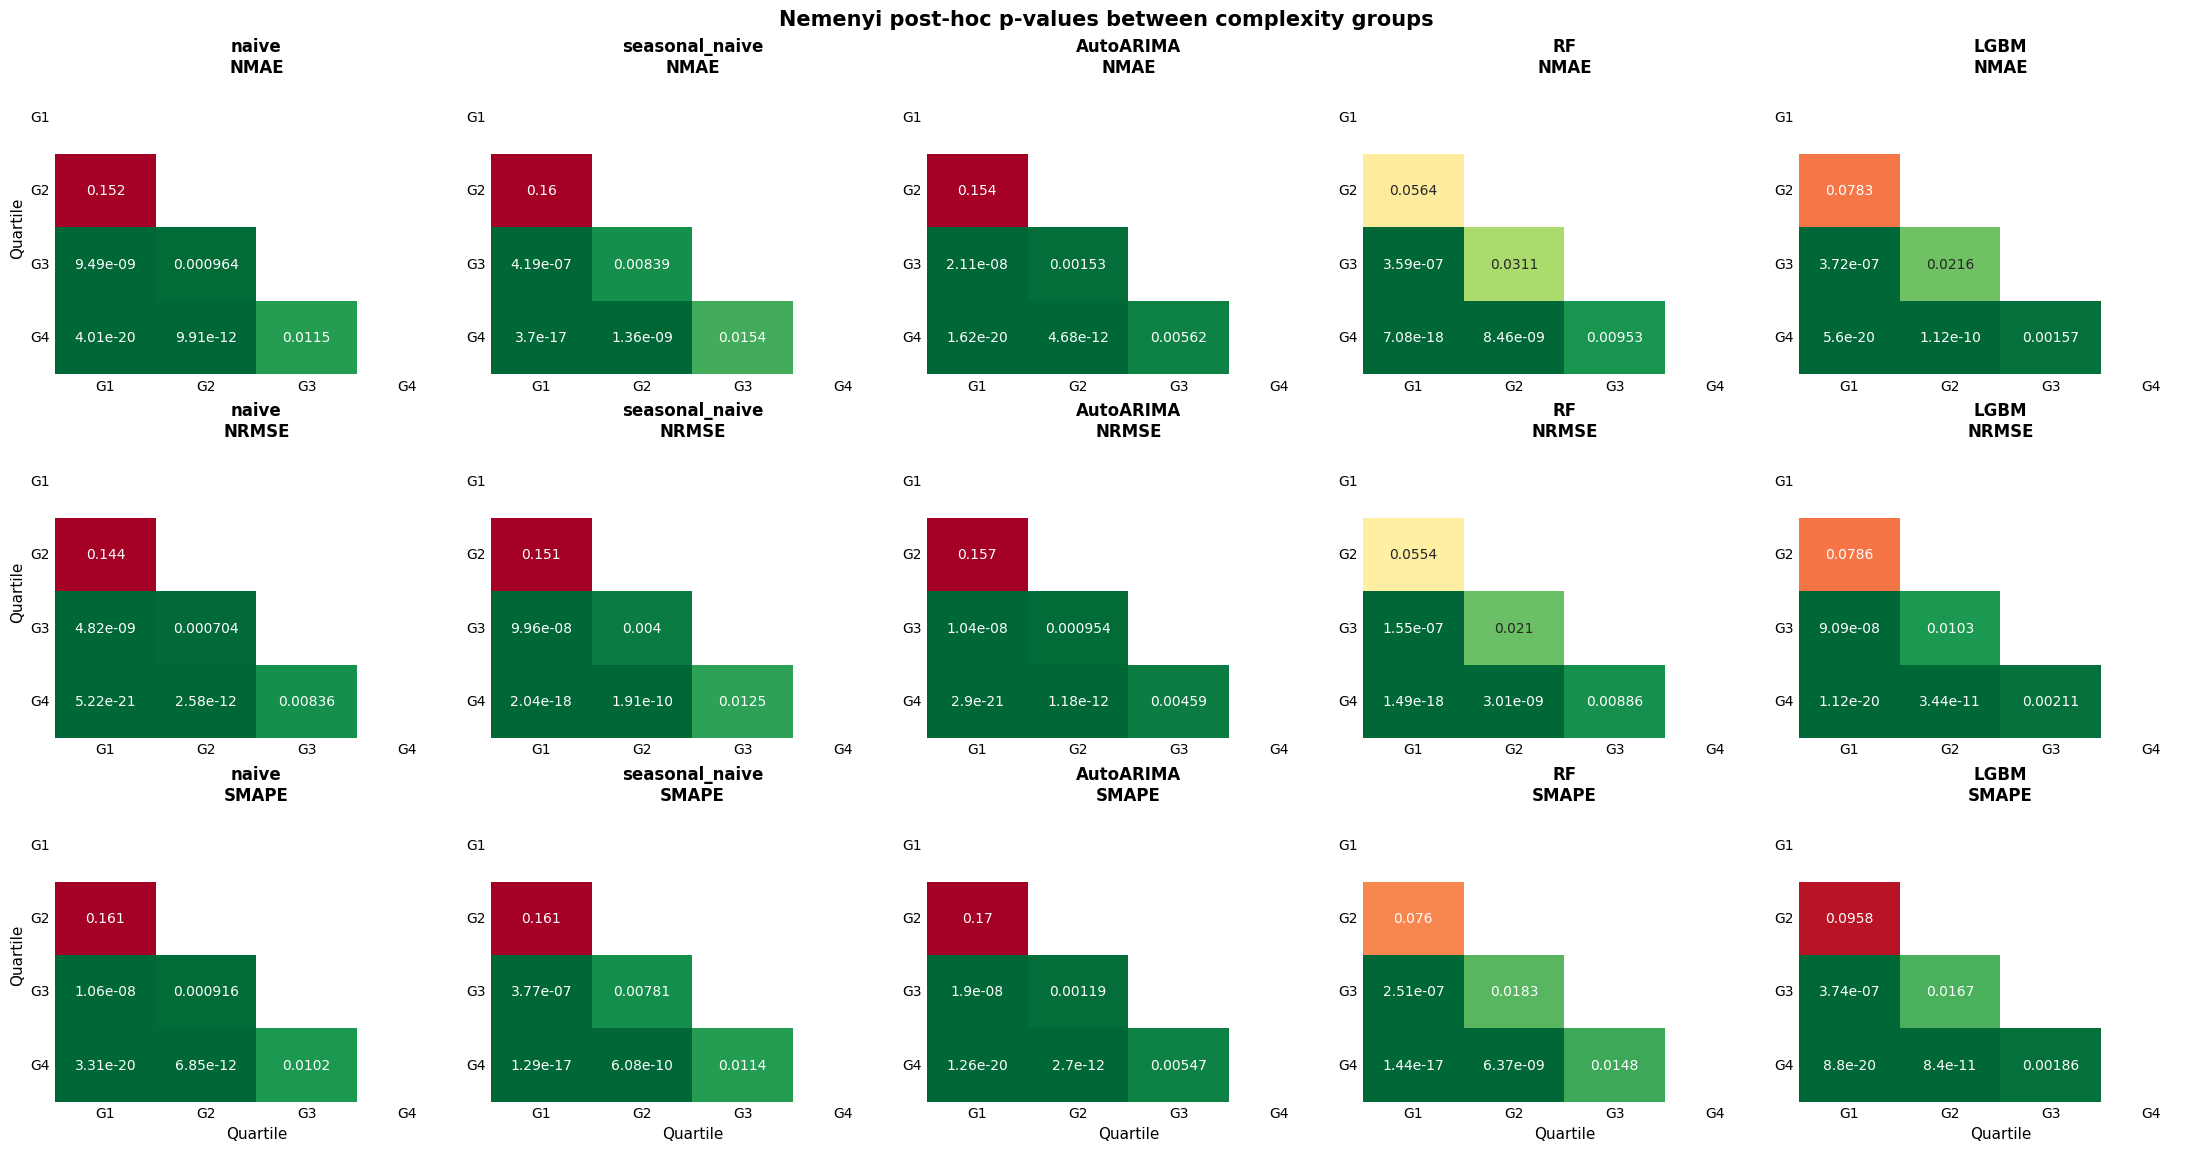

In [32]:
nemenyi_results = {}  # key: (metric, model) -> DataFrame of p-values

for _, row in kruskal_df[kruskal_df["proceed_nemenyi"]].iterrows():
    metric, model = row["metric"], row["model"]
    col = f"{metric}_{model}"

    groups = [
        df[df["complexity_group"] == g][col].dropna().values
        for g in GROUP_ORDER
    ]

    pval_matrix = sp.posthoc_nemenyi(groups, dist="chi")

    pval_matrix.index = [g.replace("\n", " ") for g in GROUP_ORDER]
    pval_matrix.columns = [g.replace("\n", " ") for g in GROUP_ORDER]

    nemenyi_results[(metric, model)] = pval_matrix


# Heatmaps
n_sig = len(nemenyi_results)

if n_sig > 0:
    ncols = len(MODELS)
    nrows = len(METRICS)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * 4.4, nrows * 3.8),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(nrows, ncols)

    for r, metric in enumerate(METRICS):
        for c, model in enumerate(MODELS):
            ax = axes[r, c]
            key = (metric, model)

            if key not in nemenyi_results:
                ax.set_facecolor("#f0f0f0")
                ax.text(
                    0.5,
                    0.5,
                    "KW n.s.",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    color="gray",
                    fontsize=11
                )
                ax.set_xticks([])
                ax.set_yticks([])

            else:
                pm = nemenyi_results[key].copy()

                # Short labels for readability
                pm.index = ["G1", "G2", "G3", "G4"]
                pm.columns = ["G1", "G2", "G3", "G4"]

                # Hide upper triangle and diagonal
                mask = np.triu(np.ones_like(pm, dtype=bool))

                sns.heatmap(
                    pm,
                    mask=mask,
                    annot=True,
                    fmt=".3g",
                    cmap="RdYlGn_r",
                    vmin=0,
                    vmax=0.1,
                    linewidths=0,
                    linecolor=None,
                    ax=ax,
                    cbar=False,
                    annot_kws={"size": 10}
                )

                for spine in ax.spines.values():
                    spine.set_visible(False)

                ax.grid(False)
                ax.tick_params(length=0)

            ax.set_title(
                f"{model}\n{metric.upper()}",
                fontsize=12,
                fontweight="bold"
            )

            ax.tick_params(axis="x", labelsize=10, rotation=0)
            ax.tick_params(axis="y", labelsize=10, rotation=0)

            if c == 0:
                ax.set_ylabel("Quartile", fontsize=11)
            else:
                ax.set_ylabel("")

            if r == nrows - 1:
                ax.set_xlabel("Quartile", fontsize=11)
            else:
                ax.set_xlabel("")

    fig.suptitle(
        "Nemenyi post-hoc p-values between complexity groups",
        fontsize=15,
        fontweight="bold"
    )

    plt.savefig("nemenyi_heatmaps.png", dpi=300, bbox_inches="tight")
    plt.savefig("nemenyi_heatmaps.pdf", bbox_inches="tight")

    plt.show()